In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

nav_df = pd.read_csv("../data/raw/02_nav_history.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

print("Shape:", nav_df.shape)
print("Columns:", nav_df.columns.tolist())
print(nav_df.head())

Shape: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [2]:

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav_df[["amfi_code", "date", "nav", "daily_return"]].head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [3]:
annualised_returns = (
    nav_df.dropna(subset=["daily_return"])
    .groupby("amfi_code")["daily_return"]
    .agg(
        n="count",
        cumulative_growth=lambda x: (1 + x).prod()
    )
    .reset_index()
)

annualised_returns["annualised_return"] = (
    annualised_returns["cumulative_growth"]
    ** (252 / annualised_returns["n"])
    - 1
)

annualised_returns = annualised_returns[
    ["amfi_code", "n", "annualised_return"]
]

print(annualised_returns)

    amfi_code     n  annualised_return
0      100016  1149           0.025435
1      100025  1149           0.042987
2      100033  1149           0.289279
3      101206  1149           0.226265
4      101207  1149           0.076502
5      101208  1149           0.062739
6      102885  1149           0.175404
7      102886  1149           0.011304
8      102887  1149           0.162055
9      118632  1149           0.231161
10     118633  1149           0.156614
11     118634  1149           0.157567
12     118635  1149           0.153571
13     118636  1149           0.051259
14     119092  1149           0.061381
15     119093  1149           0.076105
16     119094  1149           0.271025
17     119095  1149           0.014678
18     119120  1149           0.056773
19     119551  1149           0.247966
20     119552  1149           0.206968
21     119598  1149           0.311266
22     119599  1149           0.019818
23     120503  1149           0.180708
24     120504  1149      

In [5]:

returns_df = nav_df.merge(
    annualised_returns[["amfi_code", "annualised_return"]],
    on="amfi_code",
    how="left"
)

print("returns_df created successfully")
print("Shape:", returns_df.shape)
print(returns_df.head())

returns_df created successfully
Shape: (46000, 5)
   amfi_code       date       nav  daily_return  annualised_return
0     100016 2022-01-03  520.4608           NaN           0.025435
1     100016 2022-01-04  515.0971     -0.010306           0.025435
2     100016 2022-01-05  521.7239      0.012865           0.025435
3     100016 2022-01-06  515.7880     -0.011377           0.025435
4     100016 2022-01-07  515.1639     -0.001210           0.025435


In [6]:
from pathlib import Path

output_path = Path("../data/processed/returns_computed.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)

returns_df.to_csv(output_path, index=False)

print(f"Saved successfully: {output_path}")
print("Shape:", returns_df.shape)

Saved successfully: ..\data\processed\returns_computed.csv
Shape: (46000, 5)


# Day 4 - task 2 - CAGR Calculation

In [7]:

funds = (
    nav_df[["amfi_code"]]
    .drop_duplicates()
    .sort_values("amfi_code")
)

print("Number of funds:", len(funds))
print(funds.to_string(index=False))

Number of funds: 40
 amfi_code
    100016
    100025
    100033
    101206
    101207
    101208
    102885
    102886
    102887
    118632
    118633
    118634
    118635
    118636
    119092
    119093
    119094
    119095
    119120
    119551
    119552
    119598
    119599
    120503
    120504
    120505
    120506
    120507
    120841
    120842
    120843
    120844
    125497
    125498
    148567
    148568
    148569
    149322
    149323
    149324


In [8]:

nav_df["date"] = pd.to_datetime(nav_df["date"])

periods = {
    "1Y": 1,
    "3Y": 3,
    "5Y": 5
}

cagr_results = []

for amfi_code, fund_data in nav_df.groupby("amfi_code"):

    fund_data = fund_data.sort_values("date").dropna(subset=["nav"])

    end_date = fund_data["date"].max()
    end_nav = fund_data.loc[
        fund_data["date"] == end_date, "nav"
    ].iloc[0]

    for period_name, years in periods.items():

        target_start_date = end_date - pd.DateOffset(years=years)

        eligible = fund_data[
            fund_data["date"] <= target_start_date
        ]

        if eligible.empty:
            continue

        start_row = eligible.iloc[-1]

        start_date = start_row["date"]
        start_nav = start_row["nav"]

        # CAGR formula
        cagr = (end_nav / start_nav) ** (1 / years) - 1

        cagr_results.append({
            "amfi_code": amfi_code,
            "period": period_name,
            "years": years,
            "start_date": start_date,
            "end_date": end_date,
            "start_nav": start_nav,
            "end_nav": end_nav,
            "cagr": cagr
        })

cagr_report = pd.DataFrame(cagr_results)

print("Shape:", cagr_report.shape)
print(cagr_report.head(15))

Shape: (80, 8)
    amfi_code period  years start_date   end_date  start_nav   end_nav  \
0      100016     1Y      1 2025-05-29 2026-05-29   596.8877  583.6113   
1      100016     3Y      3 2023-05-29 2026-05-29   561.5519  583.6113   
2      100025     1Y      1 2025-05-29 2026-05-29    30.7452   31.8843   
3      100025     3Y      3 2023-05-29 2026-05-29    28.4135   31.8843   
4      100033     1Y      1 2025-05-29 2026-05-29   223.1951  342.0072   
5      100033     3Y      3 2023-05-29 2026-05-29   147.2155  342.0072   
6      101206     1Y      1 2025-05-29 2026-05-29   522.7639  773.2939   
7      101206     3Y      3 2023-05-29 2026-05-29   360.4971  773.2939   
8      101207     1Y      1 2025-05-29 2026-05-29    71.0180   53.9836   
9      101207     3Y      3 2023-05-29 2026-05-29    61.3081   53.9836   
10     101208     1Y      1 2025-05-29 2026-05-29   382.4272  410.1021   
11     101208     3Y      3 2023-05-29 2026-05-29   341.2705  410.1021   
12     102885     1Y   

In [9]:
cagr_report["cagr_pct"] = cagr_report["cagr"] * 100

print(
    cagr_report[
        ["amfi_code", "period", "start_date", "end_date",
         "start_nav", "end_nav", "cagr_pct"]
    ].to_string(index=False)
)

 amfi_code period start_date   end_date  start_nav   end_nav   cagr_pct
    100016     1Y 2025-05-29 2026-05-29   596.8877  583.6113  -2.224271
    100016     3Y 2023-05-29 2026-05-29   561.5519  583.6113   1.292649
    100025     1Y 2025-05-29 2026-05-29    30.7452   31.8843   3.704969
    100025     3Y 2023-05-29 2026-05-29    28.4135   31.8843   3.916390
    100033     1Y 2025-05-29 2026-05-29   223.1951  342.0072  53.232396
    100033     3Y 2023-05-29 2026-05-29   147.2155  342.0072  32.442459
    101206     1Y 2025-05-29 2026-05-29   522.7639  773.2939  47.924120
    101206     3Y 2023-05-29 2026-05-29   360.4971  773.2939  28.967695
    101207     1Y 2025-05-29 2026-05-29    71.0180   53.9836 -23.986032
    101207     3Y 2023-05-29 2026-05-29    61.3081   53.9836  -4.152381
    101208     1Y 2025-05-29 2026-05-29   382.4272  410.1021   7.236645
    101208     3Y 2023-05-29 2026-05-29   341.2705  410.1021   6.315784
    102885     1Y 2025-05-29 2026-05-29   156.2127  187.7797  20

In [10]:
from pathlib import Path

output_path = Path("../data/processed/cagr_report.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)

cagr_report.to_csv(output_path, index=False)

print(f"Saved successfully: {output_path}")
print("Shape:", cagr_report.shape)

Saved successfully: ..\data\processed\cagr_report.csv
Shape: (80, 9)


In [11]:
check = pd.read_csv(output_path)

print(check.shape)
print(check.head())
print("\nPeriods:")
print(check["period"].value_counts())

(80, 9)
   amfi_code period  years  start_date    end_date  start_nav   end_nav  \
0     100016     1Y      1  2025-05-29  2026-05-29   596.8877  583.6113   
1     100016     3Y      3  2023-05-29  2026-05-29   561.5519  583.6113   
2     100025     1Y      1  2025-05-29  2026-05-29    30.7452   31.8843   
3     100025     3Y      3  2023-05-29  2026-05-29    28.4135   31.8843   
4     100033     1Y      1  2025-05-29  2026-05-29   223.1951  342.0072   

       cagr   cagr_pct  
0 -0.022243  -2.224271  
1  0.012926   1.292649  
2  0.037050   3.704969  
3  0.039164   3.916390  
4  0.532324  53.232396  

Periods:
period
1Y    40
3Y    40
Name: count, dtype: int64


# Day 4 — Task 3: Sharpe Ratio 

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

returns_path = Path("../data/processed/returns_computed.csv")

returns_df = pd.read_csv(returns_path)

returns_df["date"] = pd.to_datetime(returns_df["date"])

print("returns_df loaded successfully")
print("Shape:", returns_df.shape)
returns_df.head()

returns_df loaded successfully
Shape: (46000, 5)


,amfi_code,date,nav,daily_return,annualised_return
0,100016,2022-01-03,520.4608,NaN,0.025435
1,100016,2022-01-04,515.0971,-0.010306,0.025435
2,100016,2022-01-05,521.7239,0.012865,0.025435
3,100016,2022-01-06,515.7880,-0.011377,0.025435
4,100016,2022-01-07,515.1639,-0.001210,0.025435


In [3]:
RF = 0.065

volatility = (
    returns_df.groupby("amfi_code")["daily_return"]
    .std()
    .reset_index(name="daily_std")
)

avg_return = (
    returns_df.groupby("amfi_code")["daily_return"]
    .mean()
    .reset_index(name="daily_mean")
)

sharpe_df = avg_return.merge(volatility, on="amfi_code")

sharpe_df["annualised_return"] = (
    (1 + sharpe_df["daily_mean"]) ** 252 - 1
)

sharpe_df["annualised_volatility"] = (
    sharpe_df["daily_std"] * np.sqrt(252)
)

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["annualised_return"] - RF)
    / sharpe_df["annualised_volatility"]
)

sharpe_df.head()

,amfi_code,daily_mean,daily_std,annualised_return,annualised_volatility,sharpe_ratio
0,100016,0.000142,0.009164,0.036325,0.145481,-0.197106
1,100025,0.000170,0.002460,0.043781,0.039052,-0.543340
2,100033,0.001080,0.011929,0.312539,0.189367,1.307193
3,101206,0.000852,0.009177,0.239311,0.145682,1.196513
4,101207,0.000424,0.016251,0.112867,0.257973,0.185550


In [4]:
output_path = Path("../data/processed/sharpe_values.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)

sharpe_df.to_csv(output_path, index=False)

print("Saved successfully:", output_path)
print("Shape:", sharpe_df.shape)

Saved successfully: ..\data\processed\sharpe_values.csv
Shape: (40, 6)


# task 4 - Compute Sortino Ratio

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

input_path = Path("../data/processed/returns_computed.csv")

returns_df = pd.read_csv(input_path)
returns_df["date"] = pd.to_datetime(returns_df["date"])

RF = 0.065

annualised_return = (
    returns_df.groupby("amfi_code")["daily_return"]
    .apply(lambda x: (1 + x.dropna()).prod() ** (252 / len(x.dropna())) - 1)
    .reset_index(name="annualised_return")
)

def downside_std(x):
    negative_returns = x.dropna()
    negative_returns = negative_returns[negative_returns < 0]

    if len(negative_returns) < 2:
        return np.nan

    return negative_returns.std(ddof=1) * np.sqrt(252)

downside = (
    returns_df.groupby("amfi_code")["daily_return"]
    .apply(downside_std)
    .reset_index(name="downside_std")
)

sortino_df = annualised_return.merge(
    downside,
    on="amfi_code",
    how="inner"
)

sortino_df["sortino_ratio"] = (
    (sortino_df["annualised_return"] - RF)
    / sortino_df["downside_std"]
)

output_path = Path("../data/processed/sortino_values.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

sortino_df.to_csv(output_path, index=False)

print("Sortino ratio calculated successfully.")
print("Shape:", sortino_df.shape)
print(sortino_df.head(10))
print(f"Saved successfully: {output_path}")

Sortino ratio calculated successfully.
Shape: (40, 4)
   amfi_code  annualised_return  downside_std  sortino_ratio
0     100016           0.025435      0.083513      -0.473761
1     100025           0.042987      0.023514      -0.936166
2     100033           0.289279      0.113229       1.980757
3     101206           0.226265      0.083157       1.939283
4     101207           0.076502      0.151683       0.075827
5     101208           0.062739      0.002457      -0.920235
6     102885           0.175404      0.073055       1.511249
7     102886           0.011304      0.107501      -0.499489
8     102887           0.162055      0.089667       1.082389
9     118632           0.231161      0.082717       2.008792
Saved successfully: ..\data\processed\sortino_values.csv


# Task 5 - Compute alpha and beta vs bencmark 

In [3]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current working directory:
c:\Users\Harishankar\project\notebooks

Files in current directory:
['.gitkeep', '.ipynb_checkpoints', 'amfi_validation.ipynb', 'database_setup.ipynb', 'EDA_Analaysis.ipynb', 'EDA_Findings.ipynb', 'fund_master_eda.ipynb', 'fund_performance.ipynb', 'nav_cleaning.ipynb', 'performance_cleaning.ipynb', 'transactions_cleaning.ipynb']


In [4]:
import os

project_path = os.path.dirname(os.getcwd())

print("Project folder:")
print(project_path)

print("\nFolders/files in project:")
print(os.listdir(project_path))

Project folder:
c:\Users\Harishankar\project

Folders/files in project:
['.git', '.gitignore', '.vscode', 'dashboard', 'data', 'data_dictionary.md', 'data_ingestion.py', 'excel', 'fetch_multiple_nav.py', 'live_nav_fetch.py', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'sql']


In [5]:
import os

project_path = os.path.dirname(os.getcwd())

print("Project folder:")
print(project_path)

print("\nFolders/files in project:")
print(os.listdir(project_path))

Project folder:
c:\Users\Harishankar\project

Folders/files in project:
['.git', '.gitignore', '.vscode', 'dashboard', 'data', 'data_dictionary.md', 'data_ingestion.py', 'excel', 'fetch_multiple_nav.py', 'live_nav_fetch.py', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'sql']


In [6]:
import os

data_path = os.path.join(project_path, "data")

print("Data folder:")
print(data_path)

print("\nFiles in data folder:")
print(os.listdir(data_path))

Data folder:
c:\Users\Harishankar\project\data

Files in data folder:
['bluestock_mf.db', 'cleaned', 'mutual_funds.db', 'processed', 'raw']


In [7]:
raw_path = os.path.join(data_path, "raw")

print("Raw data folder:")
print(raw_path)

print("\nFiles in raw folder:")
print(os.listdir(raw_path))

Raw data folder:
c:\Users\Harishankar\project\data\raw

Files in raw folder:
['.gitkeep', '01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'axis_bluechip_nav.csv', 'hdfc_top100_live_nav.csv', 'icici_bluechip_nav.csv', 'kotak_bluechip_nav.csv', 'nippon_large_cap_nav.csv', 'sbi_bluechip_nav.csv']


In [8]:
benchmark_path = os.path.join(raw_path, "10_benchmark_indices.csv")

benchmark = pd.read_csv(benchmark_path)

print("Shape:", benchmark.shape)

print("\nColumns:")
print(benchmark.columns.tolist())

print("\nFirst 5 rows:")
print(benchmark.head())

print("\nIndex names:")
print(benchmark["index_name"].unique())

Shape: (8050, 3)

Columns:
['date', 'index_name', 'close_value']

First 5 rows:
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Index names:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [9]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

print("NIFTY100 shape:", nifty100.shape)

print("\nFirst 5 rows:")
print(nifty100.head())

print("\nLast 5 rows:")
print(nifty100.tail())

print("\nDate range:")
print(nifty100["date"].min(), "to", nifty100["date"].max())

NIFTY100 shape: (1150, 3)

First 5 rows:
            date index_name  close_value
1150  2022-01-03   NIFTY100     17778.24
1151  2022-01-04   NIFTY100     17537.52
1152  2022-01-05   NIFTY100     17607.73
1153  2022-01-06   NIFTY100     17556.05
1154  2022-01-07   NIFTY100     17664.02

Last 5 rows:
            date index_name  close_value
2295  2026-05-25   NIFTY100     19245.64
2296  2026-05-26   NIFTY100     19228.08
2297  2026-05-27   NIFTY100     19489.24
2298  2026-05-28   NIFTY100     19677.97
2299  2026-05-29   NIFTY100     19696.29

Date range:
2022-01-03 to 2026-05-29


In [10]:
nifty100 = nifty100.copy()

nifty100["date"] = pd.to_datetime(nifty100["date"])
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

print("NIFTY100 shape:", nifty100.shape)

print("\nFirst 10 rows:")
print(nifty100.head(10))

print("\nMissing benchmark returns:")
print(nifty100["benchmark_return"].isna().sum())

print("\nReturn statistics:")
print(nifty100["benchmark_return"].describe())

NIFTY100 shape: (1150, 4)

First 10 rows:
           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150
1155 2022-01-10   NIFTY100     17516.51         -0.008351
1156 2022-01-11   NIFTY100     17603.08          0.004942
1157 2022-01-12   NIFTY100     17763.76          0.009128
1158 2022-01-13   NIFTY100     17830.30          0.003746
1159 2022-01-14   NIFTY100     17578.93         -0.014098

Missing benchmark returns:
1

Return statistics:
count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64


In [11]:
processed_path = os.path.join(data_path, "processed")

print("Processed data folder:")
print(processed_path)

print("\nFiles in processed folder:")
print(os.listdir(processed_path))

Processed data folder:
c:\Users\Harishankar\project\data\processed

Files in processed folder:
['.gitkeep', 'cagr_report.csv', 'returns_computed.csv', 'sharpe_values.csv', 'sortino_values.csv']


In [12]:
returns_path = os.path.join(processed_path, "returns_computed.csv")

fund_returns = pd.read_csv(returns_path)

print("Shape:", fund_returns.shape)

print("\nColumns:")
print(fund_returns.columns.tolist())

print("\nFirst 5 rows:")
print(fund_returns.head())

print("\nLast 5 rows:")
print(fund_returns.tail())

print("\nDate range:")
print(fund_returns["date"].min(), "to", fund_returns["date"].max())

print("\nNumber of funds:")
print(fund_returns["amfi_code"].nunique())

print("\nMissing daily returns:")
print(fund_returns["daily_return"].isna().sum())

Shape: (46000, 5)

Columns:
['amfi_code', 'date', 'nav', 'daily_return', 'annualised_return']

First 5 rows:
   amfi_code        date       nav  daily_return  annualised_return
0     100016  2022-01-03  520.4608           NaN           0.025435
1     100016  2022-01-04  515.0971     -0.010306           0.025435
2     100016  2022-01-05  521.7239      0.012865           0.025435
3     100016  2022-01-06  515.7880     -0.011377           0.025435
4     100016  2022-01-07  515.1639     -0.001210           0.025435

Last 5 rows:
       amfi_code        date       nav  daily_return  annualised_return
45995     149324  2026-05-25  292.4810      0.012106           0.309965
45996     149324  2026-05-26  291.2707     -0.004138           0.309965
45997     149324  2026-05-27  288.8007     -0.008480           0.309965
45998     149324  2026-05-28  280.6873     -0.028093           0.309965
45999     149324  2026-05-29  279.7511     -0.003335           0.309965

Date range:
2022-01-03 to 2026-05-29

In [13]:

fund_returns["date"] = pd.to_datetime(fund_returns["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])

fund_returns = fund_returns.sort_values("date")
nifty100 = nifty100.sort_values("date")

fund_data = fund_returns[["amfi_code", "date", "daily_return"]].copy()
benchmark_data = nifty100[["date", "benchmark_return"]].copy()

print("Fund data:")
print(fund_data.head())

print("\nBenchmark data:")
print(benchmark_data.head())

print("\nFund date range:")
print(fund_data["date"].min(), "to", fund_data["date"].max())

print("\nBenchmark date range:")
print(benchmark_data["date"].min(), "to", benchmark_data["date"].max())

Fund data:
       amfi_code       date  daily_return
0         100016 2022-01-03           NaN
5750      101208 2022-01-03           NaN
31050     120507 2022-01-03           NaN
44850     149324 2022-01-03           NaN
32200     120841 2022-01-03           NaN

Benchmark data:
           date  benchmark_return
1150 2022-01-03               NaN
1151 2022-01-04         -0.013540
1152 2022-01-05          0.004003
1153 2022-01-06         -0.002935
1154 2022-01-07          0.006150

Fund date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Benchmark date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [14]:
merged_data = pd.merge(
    fund_data,
    benchmark_data,
    on="date",
    how="inner"
)

print("Merged shape:", merged_data.shape)

print("\nFirst 10 rows:")
print(merged_data.head(10))

print("\nLast 5 rows:")
print(merged_data.tail())

print("\nMissing values:")
print(merged_data[["daily_return", "benchmark_return"]].isna().sum())

print("\nNumber of funds:")
print(merged_data["amfi_code"].nunique())

Merged shape: (46000, 4)

First 10 rows:
   amfi_code       date  daily_return  benchmark_return
0     100016 2022-01-03           NaN               NaN
1     101208 2022-01-03           NaN               NaN
2     120507 2022-01-03           NaN               NaN
3     149324 2022-01-03           NaN               NaN
4     120841 2022-01-03           NaN               NaN
5     120842 2022-01-03           NaN               NaN
6     101207 2022-01-03           NaN               NaN
7     120843 2022-01-03           NaN               NaN
8     120506 2022-01-03           NaN               NaN
9     120844 2022-01-03           NaN               NaN

Last 5 rows:
       amfi_code       date  daily_return  benchmark_return
45995     120503 2026-05-29      0.012817          0.000931
45996     119599 2026-05-29      0.021740          0.000931
45997     119598 2026-05-29     -0.005625          0.000931
45998     120841 2026-05-29     -0.004538          0.000931
45999     149324 2026-05-29  

In [15]:
regression_data = merged_data.dropna(
    subset=["daily_return", "benchmark_return"]
).copy()

print("Regression data shape:", regression_data.shape)

print("\nMissing values:")
print(regression_data[["daily_return", "benchmark_return"]].isna().sum())

print("\nNumber of funds:")
print(regression_data["amfi_code"].nunique())

print("\nRows per fund:")
print(regression_data.groupby("amfi_code").size().describe())

Regression data shape: (45960, 4)

Missing values:
daily_return        0
benchmark_return    0
dtype: int64

Number of funds:
40

Rows per fund:
count      40.0
mean     1149.0
std         0.0
min      1149.0
25%      1149.0
50%      1149.0
75%      1149.0
max      1149.0
dtype: float64


In [16]:
test_fund = regression_data["amfi_code"].iloc[0]

In [18]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.6 MB 8.7 MB/s eta 0:00:05
   ---- ----------------------------------- 3.9/36.6 MB 10.7 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/36.6 MB 10.9 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/36.6 MB 11.1 MB/s eta 0:00:03
   ------------ --------------------------- 11.0/36.6 MB 11.3 MB/s eta 0:00:03
   -------------- ------------------------- 13.4/36.6 MB 11.3 MB/s eta 0:00:03
   ----------------- ---------------------- 15.7/36.6 MB 11.4 MB/s eta 0:00:02
   ------------------- -------------------- 18.1/36.6 MB 11.4 MB/s eta 0:00:02
   ---------------------- ----------------- 20.4/36.6 MB 11.5 MB/s eta 0:00:02
   ------------------------ --------------- 22.8/36.6 MB 11.5 MB/s eta 0:00:02
   --------------------------- ------------ 25.2/36.6 MB 11.5 MB/s 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Harishankar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
import scipy
from scipy.stats import linregress

print("SciPy version:", scipy.__version__)
print("SciPy installed successfully")

SciPy version: 1.18.0
SciPy installed successfully


In [20]:
from scipy.stats import linregress
import numpy as np

test_fund = regression_data["amfi_code"].iloc[0]

fund_test_data = regression_data[
    regression_data["amfi_code"] == test_fund
]

x = fund_test_data["benchmark_return"].to_numpy()

y = fund_test_data["daily_return"].to_numpy()
result = linregress(x, y)

alpha = result.intercept * 252

beta = result.slope

print("Test Fund:", test_fund)
print("Observations:", len(fund_test_data))
print("Daily Alpha:", result.intercept)
print("Annualized Alpha:", alpha)
print("Beta:", beta)
print("R-squared:", result.rvalue ** 2)
print("P-value:", result.pvalue)

Test Fund: 119094
Observations: 1149
Daily Alpha: 0.0010347884555572276
Annualized Alpha: 0.26076669080042136
Beta: -0.06626542862803704
R-squared: 0.0019368789369602125
P-value: 0.13598752352498672


In [21]:
from scipy.stats import linregress

alpha_beta_results = []

for amfi_code, group in regression_data.groupby("amfi_code"):

    x = group["benchmark_return"].to_numpy()

    y = group["daily_return"].to_numpy()

    result = linregress(x, y)

    alpha = result.intercept * 252

    beta = result.slope

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

print("Shape:", alpha_beta.shape)

print("\nFirst 10 results:")
print(alpha_beta.head(10))

print("\nNumber of funds:")
print(alpha_beta["amfi_code"].nunique())

print("\nMissing values:")
print(alpha_beta.isna().sum())

Shape: (40, 3)

First 10 results:
   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289
5     101208  0.060861  0.000267
6     102885  0.170488 -0.019487
7     102886  0.028969 -0.042125
8     102887  0.162113  0.016683
9     118632  0.218294 -0.008354

Number of funds:
40

Missing values:
amfi_code    0
alpha        0
beta         0
dtype: int64


In [22]:
alpha_beta_path = os.path.join(
    processed_path,
    "alpha_beta.csv"
)

alpha_beta.to_csv(
    alpha_beta_path,
    index=False
)

print("File saved successfully:")
print(alpha_beta_path)

File saved successfully:
c:\Users\Harishankar\project\data\processed\alpha_beta.csv


In [23]:
check_alpha_beta = pd.read_csv(alpha_beta_path)

print("Shape:", check_alpha_beta.shape)

print("\nColumns:")
print(check_alpha_beta.columns.tolist())

print("\nFirst 10 rows:")
print(check_alpha_beta.head(10))

print("\nMissing values:")
print(check_alpha_beta.isna().sum())

Shape: (40, 3)

Columns:
['amfi_code', 'alpha', 'beta']

First 10 rows:
   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289
5     101208  0.060861  0.000267
6     102885  0.170488 -0.019487
7     102886  0.028969 -0.042125
8     102887  0.162113  0.016683
9     118632  0.218294 -0.008354

Missing values:
amfi_code    0
alpha        0
beta         0
dtype: int64


# task 6 - Compute Maximum drawdown 

In [24]:
import pandas as pd
import numpy as np
import os

project_path = os.path.dirname(os.getcwd())
data_path = os.path.join(project_path, "data")
processed_path = os.path.join(data_path, "processed")


returns_path = os.path.join(
    processed_path,
    "returns_computed.csv"
)

fund_data = pd.read_csv(returns_path)

print("Shape:", fund_data.shape)

print("\nColumns:")
print(fund_data.columns.tolist())

print("\nFirst 5 rows:")
print(fund_data.head())

print("\nDate range:")
print(fund_data["date"].min(), "to", fund_data["date"].max())

print("\nNumber of funds:")
print(fund_data["amfi_code"].nunique())

print("\nMissing NAV values:")
print(fund_data["nav"].isna().sum())

Shape: (46000, 5)

Columns:
['amfi_code', 'date', 'nav', 'daily_return', 'annualised_return']

First 5 rows:
   amfi_code        date       nav  daily_return  annualised_return
0     100016  2022-01-03  520.4608           NaN           0.025435
1     100016  2022-01-04  515.0971     -0.010306           0.025435
2     100016  2022-01-05  521.7239      0.012865           0.025435
3     100016  2022-01-06  515.7880     -0.011377           0.025435
4     100016  2022-01-07  515.1639     -0.001210           0.025435

Date range:
2022-01-03 to 2026-05-29

Number of funds:
40

Missing NAV values:
0


In [25]:

fund_data["date"] = pd.to_datetime(fund_data["date"])

fund_data = fund_data.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("Sorted data:")
print(fund_data.head(10))

print("\nDate range:")
print(fund_data["date"].min(), "to", fund_data["date"].max())

print("\nNumber of funds:")
print(fund_data["amfi_code"].nunique())

print("\nIs data sorted correctly?")
print(
    fund_data.groupby("amfi_code")["date"]
    .apply(lambda x: x.is_monotonic_increasing)
    .all()
)

Sorted data:
   amfi_code       date       nav  daily_return  annualised_return
0     100016 2022-01-03  520.4608           NaN           0.025435
1     100016 2022-01-04  515.0971     -0.010306           0.025435
2     100016 2022-01-05  521.7239      0.012865           0.025435
3     100016 2022-01-06  515.7880     -0.011377           0.025435
4     100016 2022-01-07  515.1639     -0.001210           0.025435
5     100016 2022-01-10  510.7136     -0.008639           0.025435
6     100016 2022-01-11  513.5542      0.005562           0.025435
7     100016 2022-01-12  512.3195     -0.002404           0.025435
8     100016 2022-01-13  510.2445     -0.004050           0.025435
9     100016 2022-01-14  514.3636      0.008073           0.025435

Date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Number of funds:
40

Is data sorted correctly?
True


In [26]:

fund_data["running_max_nav"] = (
    fund_data
    .groupby("amfi_code")["nav"]
    .cummax()
)

print("First 10 rows:")
print(
    fund_data[
        ["amfi_code", "date", "nav", "running_max_nav"]
    ].head(10)
)

print("\nChecking running maximum:")
print(
    fund_data[
        ["amfi_code", "nav", "running_max_nav"]
    ].head(20)
)

print("\nMissing running maximum values:")
print(fund_data["running_max_nav"].isna().sum())

First 10 rows:
   amfi_code       date       nav  running_max_nav
0     100016 2022-01-03  520.4608         520.4608
1     100016 2022-01-04  515.0971         520.4608
2     100016 2022-01-05  521.7239         521.7239
3     100016 2022-01-06  515.7880         521.7239
4     100016 2022-01-07  515.1639         521.7239
5     100016 2022-01-10  510.7136         521.7239
6     100016 2022-01-11  513.5542         521.7239
7     100016 2022-01-12  512.3195         521.7239
8     100016 2022-01-13  510.2445         521.7239
9     100016 2022-01-14  514.3636         521.7239

Checking running maximum:
    amfi_code       nav  running_max_nav
0      100016  520.4608         520.4608
1      100016  515.0971         520.4608
2      100016  521.7239         521.7239
3      100016  515.7880         521.7239
4      100016  515.1639         521.7239
5      100016  510.7136         521.7239
6      100016  513.5542         521.7239
7      100016  512.3195         521.7239
8      100016  510.2445     

In [27]:

fund_data["drawdown"] = (
    fund_data["nav"] / fund_data["running_max_nav"]
) - 1

print("First 20 rows:")
print(
    fund_data[
        ["amfi_code", "date", "nav", "running_max_nav", "drawdown"]
    ].head(20)
)

print("\nDrawdown statistics:")
print(fund_data["drawdown"].describe())

print("\nMissing drawdown values:")
print(fund_data["drawdown"].isna().sum())

print("\nMaximum drawdown value:")
print(fund_data["drawdown"].min())

First 20 rows:
    amfi_code       date       nav  running_max_nav  drawdown
0      100016 2022-01-03  520.4608         520.4608  0.000000
1      100016 2022-01-04  515.0971         520.4608 -0.010306
2      100016 2022-01-05  521.7239         521.7239  0.000000
3      100016 2022-01-06  515.7880         521.7239 -0.011377
4      100016 2022-01-07  515.1639         521.7239 -0.012574
5      100016 2022-01-10  510.7136         521.7239 -0.021104
6      100016 2022-01-11  513.5542         521.7239 -0.015659
7      100016 2022-01-12  512.3195         521.7239 -0.018026
8      100016 2022-01-13  510.2445         521.7239 -0.022003
9      100016 2022-01-14  514.3636         521.7239 -0.014108
10     100016 2022-01-17  514.7627         521.7239 -0.013343
11     100016 2022-01-18  517.3803         521.7239 -0.008325
12     100016 2022-01-19  513.1866         521.7239 -0.016364
13     100016 2022-01-20  507.1294         521.7239 -0.027974
14     100016 2022-01-21  507.8710         521.7239 -0.

In [28]:

worst_idx = fund_data.groupby("amfi_code")["drawdown"].idxmin()

max_drawdown = fund_data.loc[
    worst_idx,
    ["amfi_code", "date", "nav", "running_max_nav", "drawdown"]
].copy()

max_drawdown = max_drawdown.rename(
    columns={
        "date": "worst_drawdown_date",
        "nav": "nav_at_worst",
        "running_max_nav": "peak_nav",
        "drawdown": "max_drawdown"
    }
)

max_drawdown = max_drawdown.sort_values(
    "max_drawdown"
).reset_index(drop=True)

print("Shape:", max_drawdown.shape)

print("\nWorst drawdown for each fund:")
print(max_drawdown.head(10))

print("\nNumber of funds:")
print(max_drawdown["amfi_code"].nunique())

print("\nMissing values:")
print(max_drawdown.isna().sum())

Shape: (40, 5)

Worst drawdown for each fund:
   amfi_code worst_drawdown_date  nav_at_worst  peak_nav  max_drawdown
0     119599          2025-10-28       78.6152  165.7647     -0.525742
1     119095          2026-05-11       51.6185  106.8214     -0.516778
2     101207          2026-05-11       51.8695   80.3517     -0.354469
3     149324          2025-01-03      120.0806  174.4645     -0.311719
4     119598          2025-05-14      160.5863  225.2452     -0.287060
5     102886          2026-04-27      122.2659  169.8164     -0.280011
6     100016          2022-09-15      411.1759  546.3002     -0.247344
7     120842          2024-10-17       60.8608   80.0837     -0.240035
8     118634          2026-02-20       97.1392  126.7224     -0.233449
9     119093          2023-05-22       33.0339   42.2166     -0.217514

Number of funds:
40

Missing values:
amfi_code              0
worst_drawdown_date    0
nav_at_worst           0
peak_nav               0
max_drawdown           0
dtype: int

In [29]:
max_drawdown_path = os.path.join(
    processed_path,
    "max_drawdown.csv"
)

max_drawdown.to_csv(
    max_drawdown_path,
    index=False
)

print("File saved successfully:")
print(max_drawdown_path)

File saved successfully:
c:\Users\Harishankar\project\data\processed\max_drawdown.csv


In [30]:
check_max_drawdown = pd.read_csv(max_drawdown_path)

print("Shape:", check_max_drawdown.shape)

print("\nColumns:")
print(check_max_drawdown.columns.tolist())

print("\nFirst 10 rows:")
print(check_max_drawdown.head(10))

print("\nMissing values:")
print(check_max_drawdown.isna().sum())

Shape: (40, 5)

Columns:
['amfi_code', 'worst_drawdown_date', 'nav_at_worst', 'peak_nav', 'max_drawdown']

First 10 rows:
   amfi_code worst_drawdown_date  nav_at_worst  peak_nav  max_drawdown
0     119599          2025-10-28       78.6152  165.7647     -0.525742
1     119095          2026-05-11       51.6185  106.8214     -0.516778
2     101207          2026-05-11       51.8695   80.3517     -0.354469
3     149324          2025-01-03      120.0806  174.4645     -0.311719
4     119598          2025-05-14      160.5863  225.2452     -0.287060
5     102886          2026-04-27      122.2659  169.8164     -0.280011
6     100016          2022-09-15      411.1759  546.3002     -0.247344
7     120842          2024-10-17       60.8608   80.0837     -0.240035
8     118634          2026-02-20       97.1392  126.7224     -0.233449
9     119093          2023-05-22       33.0339   42.2166     -0.217514

Missing values:
amfi_code              0
worst_drawdown_date    0
nav_at_worst           0
peak_

# task 7 - Build Fund Scorecard

In [32]:
import pandas as pd
import numpy as np
import os

project_path = os.path.dirname(os.getcwd())
data_path = os.path.join(project_path, "data")
processed_path = os.path.join(data_path, "processed")
raw_path = os.path.join(data_path, "raw")

cagr = pd.read_csv(
    os.path.join(processed_path, "cagr_report.csv")
)

sharpe = pd.read_csv(
    os.path.join(processed_path, "sharpe_values.csv")
)

alpha_beta = pd.read_csv(
    os.path.join(processed_path, "alpha_beta.csv")
)

max_dd = pd.read_csv(
    os.path.join(processed_path, "max_drawdown.csv")
)


fund_master = pd.read_csv(
    os.path.join(raw_path, "01_fund_master.csv"),
    sep="\t"
)

print("CAGR shape:", cagr.shape)
print("Sharpe shape:", sharpe.shape)
print("Alpha/Beta shape:", alpha_beta.shape)
print("Max Drawdown shape:", max_dd.shape)
print("Fund Master shape:", fund_master.shape)

print("\nCAGR columns:")
print(cagr.columns.tolist())

print("\nSharpe columns:")
print(sharpe.columns.tolist())

print("\nAlpha/Beta columns:")
print(alpha_beta.columns.tolist())

print("\nMax Drawdown columns:")
print(max_dd.columns.tolist())

print("\nFund Master columns:")
print(fund_master.columns.tolist())

CAGR shape: (80, 9)
Sharpe shape: (40, 6)
Alpha/Beta shape: (40, 3)
Max Drawdown shape: (40, 5)
Fund Master shape: (40, 1)

CAGR columns:
['amfi_code', 'period', 'years', 'start_date', 'end_date', 'start_nav', 'end_nav', 'cagr', 'cagr_pct']

Sharpe columns:
['amfi_code', 'daily_mean', 'daily_std', 'annualised_return', 'annualised_volatility', 'sharpe_ratio']

Alpha/Beta columns:
['amfi_code', 'alpha', 'beta']

Max Drawdown columns:
['amfi_code', 'worst_drawdown_date', 'nav_at_worst', 'peak_nav', 'max_drawdown']

Fund Master columns:
['amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code']


In [33]:

fund_master = pd.read_csv(
    os.path.join(raw_path, "01_fund_master.csv"),
    sep=","
)

print("Fund Master shape:", fund_master.shape)

print("\nFund Master columns:")
print(fund_master.columns.tolist())

print("\nFirst 5 rows:")
print(
    fund_master[
        ["amfi_code", "scheme_name", "expense_ratio_pct"]
    ].head()
)

print("\nMissing expense ratios:")
print(fund_master["expense_ratio_pct"].isna().sum())

print("\nNumber of funds:")
print(fund_master["amfi_code"].nunique())

Fund Master shape: (40, 15)

Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

First 5 rows:
   amfi_code                                   scheme_name  expense_ratio_pct
0     119551     SBI Bluechip Fund - Regular Plan - Growth               1.54
1     119552      SBI Bluechip Fund - Direct Plan - Growth               0.66
2     119598    SBI Small Cap Fund - Regular Plan - Growth               1.43
3     119599     SBI Small Cap Fund - Direct Plan - Growth               0.72
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth               0.77

Missing expense ratios:
0

Number of funds:
40


In [34]:

cagr_3yr = cagr[cagr["period"] == "3Y"].copy()

print("3-Year CAGR shape:", cagr_3yr.shape)

print("\nFirst 10 rows:")
print(
    cagr_3yr[
        ["amfi_code", "period", "cagr_pct"]
    ].head(10)
)

print("\nNumber of funds:")
print(cagr_3yr["amfi_code"].nunique())

print("\nMissing 3-year CAGR values:")
print(cagr_3yr["cagr_pct"].isna().sum())

print("\nDuplicate AMFI codes:")
print(cagr_3yr["amfi_code"].duplicated().sum())

3-Year CAGR shape: (40, 9)

First 10 rows:
    amfi_code period   cagr_pct
1      100016     3Y   1.292649
3      100025     3Y   3.916390
5      100033     3Y  32.442459
7      101206     3Y  28.967695
9      101207     3Y  -4.152381
11     101208     3Y   6.315784
13     102885     3Y  19.667262
15     102886     3Y  -0.767406
17     102887     3Y  25.556188
19     118632     3Y  22.652360

Number of funds:
40

Missing 3-year CAGR values:
0

Duplicate AMFI codes:
0


In [35]:

cagr_score = cagr_3yr[
    ["amfi_code", "cagr_pct"]
].copy()

sharpe_score = sharpe[
    ["amfi_code", "sharpe_ratio"]
].copy()

alpha_score = alpha_beta[
    ["amfi_code", "alpha"]
].copy()

expense_score = fund_master[
    ["amfi_code", "expense_ratio_pct"]
].copy()

drawdown_score = max_dd[
    ["amfi_code", "max_drawdown"]
].copy()


scorecard = cagr_score.merge(
    sharpe_score,
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    alpha_score,
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    expense_score,
    on="amfi_code",
    how="inner"
)

scorecard = scorecard.merge(
    drawdown_score,
    on="amfi_code",
    how="inner"
)


print("Scorecard shape:", scorecard.shape)

print("\nColumns:")
print(scorecard.columns.tolist())

print("\nFirst 10 rows:")
print(scorecard.head(10))

print("\nMissing values:")
print(scorecard.isna().sum())

print("\nNumber of funds:")
print(scorecard["amfi_code"].nunique())

Scorecard shape: (40, 6)

Columns:
['amfi_code', 'cagr_pct', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown']

First 10 rows:
   amfi_code   cagr_pct  sharpe_ratio     alpha  expense_ratio_pct  \
0     100016   1.292649     -0.197106  0.037476               1.55   
1     100025   3.916390     -0.543340  0.042818               0.56   
2     100033  32.442459      1.307193  0.271954               1.38   
3     101206  28.967695      1.196513  0.213998               1.60   
4     101207  -4.152381      0.185550  0.108971               1.53   
5     101208   6.315784     -0.443771  0.060861               0.79   
6     102885  19.667262      0.935637  0.170488               1.57   
7     102886  -0.767406     -0.203709  0.028969               1.51   
8     102887  25.556188      0.707781  0.162113               1.64   
9     118632  22.652360      1.261743  0.218294               1.51   

   max_drawdown  
0     -0.247344  
1     -0.043083  
2     -0.162172  
3     -0.112916  


In [39]:

# Higher is better
scorecard["return_rank"] = (
    scorecard["cagr_pct"]
    .rank(ascending=False, method="min")
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False, method="min")
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False, method="min")
)


# Lower is better
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True, method="min")
)

scorecard["max_dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False, method="min")
)


print("Rank columns created successfully.")

print("\nFirst 10 ranked records:")
print(
    scorecard[
        [
            "amfi_code",
            "cagr_pct",
            "return_rank",
            "sharpe_ratio",
            "sharpe_rank",
            "alpha",
            "alpha_rank",
            "expense_ratio_pct",
            "expense_rank",
            "max_drawdown",
            "max_dd_rank"
        ]
    ].head(10)
)

Rank columns created successfully.

First 10 ranked records:
   amfi_code   cagr_pct  return_rank  sharpe_ratio  sharpe_rank     alpha  \
0     100016   1.292649         35.0     -0.197106         36.0  0.037476   
1     100025   3.916390         34.0     -0.543340         40.0  0.042818   
2     100033  32.442459          4.0      1.307193          7.0  0.271954   
3     101206  28.967695          9.0      1.196513          9.0  0.213998   
4     101207  -4.152381         39.0      0.185550         29.0  0.108971   
5     101208   6.315784         31.0     -0.443771         39.0  0.060861   
6     102885  19.667262         18.0      0.935637         17.0  0.170488   
7     102886  -0.767406         37.0     -0.203709         37.0  0.028969   
8     102887  25.556188         13.0      0.707781         23.0  0.162113   
9     118632  22.652360         14.0      1.261743          8.0  0.218294   

   alpha_rank  expense_ratio_pct  expense_rank  max_drawdown  max_dd_rank  
0        39.0  

In [40]:

n = len(scorecard)
scorecard["return_score"] = (
    (n - scorecard["return_rank"]) / (n - 1)
) * 100

scorecard["sharpe_score"] = (
    (n - scorecard["sharpe_rank"]) / (n - 1)
) * 100

scorecard["alpha_score"] = (
    (n - scorecard["alpha_rank"]) / (n - 1)
) * 100

scorecard["expense_score"] = (
    (n - scorecard["expense_rank"]) / (n - 1)
) * 100

scorecard["max_dd_score"] = (
    (n - scorecard["max_dd_rank"]) / (n - 1)
) * 100


print("Normalized scores created successfully.")

print("\nFirst 10 records:")
print(
    scorecard[
        [
            "amfi_code",
            "return_score",
            "sharpe_score",
            "alpha_score",
            "expense_score",
            "max_dd_score"
        ]
    ].head(10)
)

print("\nScore ranges:")
print(
    scorecard[
        [
            "return_score",
            "sharpe_score",
            "alpha_score",
            "expense_score",
            "max_dd_score"
        ]
    ].agg(["min", "max"])
)

Normalized scores created successfully.

First 10 records:
   amfi_code  return_score  sharpe_score  alpha_score  expense_score  \
0     100016     12.820513     10.256410     2.564103      20.512821   
1     100025     15.384615      0.000000     5.128205      97.435897   
2     100033     92.307692     84.615385    87.179487      61.538462   
3     101206     79.487179     79.487179    71.794872      10.256410   
4     101207      2.564103     28.205128    33.333333      30.769231   
5     101208     23.076923      2.564103    17.948718      74.358974   
6     102885     56.410256     58.974359    53.846154      15.384615   
7     102886      7.692308      7.692308     0.000000      41.025641   
8     102887     69.230769     43.589744    48.717949       2.564103   
9     118632     66.666667     82.051282    74.358974      41.025641   

   max_dd_score  
0     15.384615  
1     92.307692  
2     51.282051  
3     79.487179  
4      5.128205  
5     94.871795  
6     84.615385  
7   

In [41]:

scorecard["fund_score"] = (
    0.30 * scorecard["return_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["max_dd_score"]
)

print("Composite fund scores calculated successfully.")

print("\nFirst 10 scores:")
print(
    scorecard[
        [
            "amfi_code",
            "return_score",
            "sharpe_score",
            "alpha_score",
            "expense_score",
            "max_dd_score",
            "fund_score"
        ]
    ].head(10)
)

print("\nScore statistics:")
print(
    scorecard["fund_score"].describe()
)

print("\nScore range:")
print(
    scorecard["fund_score"].min(),
    "to",
    scorecard["fund_score"].max()
)

Composite fund scores calculated successfully.

First 10 scores:
   amfi_code  return_score  sharpe_score  alpha_score  expense_score  \
0     100016     12.820513     10.256410     2.564103      20.512821   
1     100025     15.384615      0.000000     5.128205      97.435897   
2     100033     92.307692     84.615385    87.179487      61.538462   
3     101206     79.487179     79.487179    71.794872      10.256410   
4     101207      2.564103     28.205128    33.333333      30.769231   
5     101208     23.076923      2.564103    17.948718      74.358974   
6     102885     56.410256     58.974359    53.846154      15.384615   
7     102886      7.692308      7.692308     0.000000      41.025641   
8     102887     69.230769     43.589744    48.717949       2.564103   
9     118632     66.666667     82.051282    74.358974      41.025641   

   max_dd_score  fund_score  
0     15.384615   11.538462  
1     92.307692   29.487179  
2     51.282051   80.641026  
3     79.487179   67.5

In [42]:

scorecard = scorecard.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)


scorecard["fund_rank"] = (
    scorecard["fund_score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

scorecard = scorecard.sort_values(
    "fund_rank"
).reset_index(drop=True)


print("Final scorecard prepared.")

print("\nTop 10 funds:")
print(
    scorecard[
        [
            "fund_rank",
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ].head(10)
)

print("\nNumber of funds:")
print(scorecard["amfi_code"].nunique())

print("\nMissing values:")
print(
    scorecard[
        [
            "fund_rank",
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ].isna().sum()
)

Final scorecard prepared.

Top 10 funds:
   fund_rank  amfi_code                                        scheme_name  \
0          1     148567      Mirae Asset Large Cap Fund - Regular - Growth   
1          2     120505           ICICI Pru Midcap Fund - Regular - Growth   
2          3     120843             Kotak Flexicap Fund - Regular - Growth   
3          4     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4          5     120504          ICICI Pru Bluechip Fund - Direct - Growth   
5          6     119094                Axis Midcap Fund - Regular - Growth   
6          7     119551          SBI Bluechip Fund - Regular Plan - Growth   
7          8     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
8          9     101206      ABSL Frontline Equity Fund - Regular - Growth   
9         10     119598         SBI Small Cap Fund - Regular Plan - Growth   

   fund_score  
0   85.897436  
1   82.435897  
2   81.538462  
3   80.641026  
4   79.487179  
5   

In [43]:


final_scorecard = scorecard[
    [
        "fund_rank",
        "amfi_code",
        "scheme_name",
        "cagr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "return_score",
        "sharpe_score",
        "alpha_score",
        "expense_score",
        "max_dd_score",
        "fund_score"
    ]
].copy()


final_scorecard["cagr_pct"] = final_scorecard["cagr_pct"].round(2)
final_scorecard["sharpe_ratio"] = final_scorecard["sharpe_ratio"].round(4)
final_scorecard["alpha"] = final_scorecard["alpha"].round(4)
final_scorecard["expense_ratio_pct"] = final_scorecard["expense_ratio_pct"].round(2)
final_scorecard["max_drawdown"] = final_scorecard["max_drawdown"].round(4)

final_scorecard[
    [
        "return_score",
        "sharpe_score",
        "alpha_score",
        "expense_score",
        "max_dd_score",
        "fund_score"
    ]
] = final_scorecard[
    [
        "return_score",
        "sharpe_score",
        "alpha_score",
        "expense_score",
        "max_dd_score",
        "fund_score"
    ]
].round(2)


output_path = os.path.join(
    processed_path,
    "fund_scorecard.csv"
)

final_scorecard.to_csv(
    output_path,
    index=False
)

print("File saved successfully:")
print(output_path)

print("\nShape:")
print(final_scorecard.shape)

print("\nColumns:")
print(final_scorecard.columns.tolist())

File saved successfully:
c:\Users\Harishankar\project\data\processed\fund_scorecard.csv

Shape:
(40, 14)

Columns:
['fund_rank', 'amfi_code', 'scheme_name', 'cagr_pct', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown', 'return_score', 'sharpe_score', 'alpha_score', 'expense_score', 'max_dd_score', 'fund_score']


# task 8 - Benchmark Comparison

In [44]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

project_path = r"C:\Users\Harishankar\project"
data_path = os.path.join(project_path, "data")

processed_path = os.path.join(data_path, "processed")
raw_path = os.path.join(data_path, "raw")


returns = pd.read_csv(
    os.path.join(processed_path, "returns_computed.csv")
)


benchmark = pd.read_csv(
    os.path.join(raw_path, "10_benchmark_indices.csv")
)


scorecard = pd.read_csv(
    os.path.join(processed_path, "fund_scorecard.csv")
)

print("Fund returns shape:", returns.shape)
print("Benchmark shape:", benchmark.shape)
print("Scorecard shape:", scorecard.shape)

print("\nFund returns columns:")
print(returns.columns.tolist())

print("\nBenchmark columns:")
print(benchmark.columns.tolist())

print("\nScorecard columns:")
print(scorecard.columns.tolist())

Fund returns shape: (46000, 5)
Benchmark shape: (8050, 3)
Scorecard shape: (40, 14)

Fund returns columns:
['amfi_code', 'date', 'nav', 'daily_return', 'annualised_return']

Benchmark columns:
['date', 'index_name', 'close_value']

Scorecard columns:
['fund_rank', 'amfi_code', 'scheme_name', 'cagr_pct', 'sharpe_ratio', 'alpha', 'expense_ratio_pct', 'max_drawdown', 'return_score', 'sharpe_score', 'alpha_score', 'expense_score', 'max_dd_score', 'fund_score']


In [45]:


top5 = (
    scorecard
    .sort_values("fund_rank")
    .head(5)
    .copy()
)

print("Top 5 Funds:")
print(
    top5[
        [
            "fund_rank",
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ]
)

print("\nNumber of top funds:")
print(top5["amfi_code"].nunique())

print("\nTop 5 AMFI codes:")
print(top5["amfi_code"].tolist())

Top 5 Funds:
   fund_rank  amfi_code                                        scheme_name  \
0          1     148567      Mirae Asset Large Cap Fund - Regular - Growth   
1          2     120505           ICICI Pru Midcap Fund - Regular - Growth   
2          3     120843             Kotak Flexicap Fund - Regular - Growth   
3          4     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4          5     120504          ICICI Pru Bluechip Fund - Direct - Growth   

   fund_score  
0       85.90  
1       82.44  
2       81.54  
3       80.64  
4       79.49  

Number of top funds:
5

Top 5 AMFI codes:
[148567, 120505, 120843, 100033, 120504]


In [46]:

returns["date"] = pd.to_datetime(returns["date"])

top5_codes = top5["amfi_code"].tolist()

top5_returns = returns[
    returns["amfi_code"].isin(top5_codes)
].copy()


top5_returns = top5_returns.dropna(
    subset=["daily_return"]
)

print("Top 5 returns shape:", top5_returns.shape)

print("\nObservations per fund:")
print(
    top5_returns.groupby("amfi_code").size()
)

print("\nDate range:")
print("Start:", top5_returns["date"].min())
print("End:", top5_returns["date"].max())

print("\nMissing daily returns:")
print(
    top5_returns["daily_return"].isna().sum()
)

print("\nUnique funds:")
print(top5_returns["amfi_code"].nunique())

Top 5 returns shape: (5745, 5)

Observations per fund:
amfi_code
100033    1149
120504    1149
120505    1149
120843    1149
148567    1149
dtype: int64

Date range:
Start: 2022-01-04 00:00:00
End: 2026-05-29 00:00:00

Missing daily returns:
0

Unique funds:
5


In [47]:

top5_returns = top5_returns.sort_values(
    ["amfi_code", "date"]
).copy()

top5_3yr = (
    top5_returns
    .groupby("amfi_code", group_keys=False)
    .tail(756)
    .copy()
)

print("Top 5 three-year returns shape:", top5_3yr.shape)

print("\nObservations per fund:")
print(
    top5_3yr.groupby("amfi_code").size()
)

print("\n3-year date range:")
print("Start:", top5_3yr["date"].min())
print("End:", top5_3yr["date"].max())

print("\nMissing returns:")
print(
    top5_3yr["daily_return"].isna().sum()
)

Top 5 three-year returns shape: (3780, 5)

Observations per fund:
amfi_code
100033    756
120504    756
120505    756
120843    756
148567    756
dtype: int64

3-year date range:
Start: 2023-07-07 00:00:00
End: 2026-05-29 00:00:00

Missing returns:
0


In [48]:

benchmark["date"] = pd.to_datetime(benchmark["date"])


benchmark_selected = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_selected = benchmark_selected.sort_values(
    ["index_name", "date"]
).copy()

benchmark_selected["benchmark_return"] = (
    benchmark_selected
    .groupby("index_name")["close_value"]
    .pct_change()
)

benchmark_3yr = (
    benchmark_selected[
        benchmark_selected["date"].between(
            top5_3yr["date"].min(),
            top5_3yr["date"].max()
        )
    ]
    .dropna(subset=["benchmark_return"])
    .copy()
)

print("Benchmark 3-year shape:", benchmark_3yr.shape)

print("\nObservations per benchmark:")
print(
    benchmark_3yr.groupby("index_name").size()
)

print("\nDate range:")
print("Start:", benchmark_3yr["date"].min())
print("End:", benchmark_3yr["date"].max())

print("\nMissing benchmark returns:")
print(
    benchmark_3yr["benchmark_return"].isna().sum()
)

print("\nBenchmark names:")
print(
    benchmark_3yr["index_name"].unique()
)

Benchmark 3-year shape: (1512, 4)

Observations per benchmark:
index_name
NIFTY100    756
NIFTY50     756
dtype: int64

Date range:
Start: 2023-07-07 00:00:00
End: 2026-05-29 00:00:00

Missing benchmark returns:
0

Benchmark names:
<StringArray>
['NIFTY100', 'NIFTY50']
Length: 2, dtype: str


In [49]:


benchmark_pivot = (
    benchmark_3yr
    .pivot(
        index="date",
        columns="index_name",
        values="benchmark_return"
    )
    .reset_index()
)

benchmark_pivot = benchmark_pivot.rename(
    columns={
        "NIFTY50": "nifty50_return",
        "NIFTY100": "nifty100_return"
    }
)

comparison_data = top5_3yr[
    ["amfi_code", "date", "daily_return"]
].merge(
    benchmark_pivot,
    on="date",
    how="inner"
)

print("Comparison data shape:", comparison_data.shape)

print("\nFirst 10 rows:")
print(comparison_data.head(10))

print("\nMissing values:")
print(
    comparison_data[
        ["daily_return", "nifty50_return", "nifty100_return"]
    ].isna().sum()
)

print("\nNumber of funds:")
print(comparison_data["amfi_code"].nunique())

print("\nObservations per fund:")
print(
    comparison_data.groupby("amfi_code").size()
)

Comparison data shape: (3780, 5)

First 10 rows:
   amfi_code       date  daily_return  nifty100_return  nifty50_return
0     100033 2023-07-07      0.002930         0.019007        0.002100
1     100033 2023-07-10     -0.009468         0.002926       -0.000191
2     100033 2023-07-11      0.008675         0.006121        0.008110
3     100033 2023-07-12      0.027493        -0.012975       -0.004097
4     100033 2023-07-13     -0.008702         0.007500        0.003510
5     100033 2023-07-14      0.004663         0.002788       -0.005809
6     100033 2023-07-17     -0.020131         0.006528       -0.002347
7     100033 2023-07-18      0.006126        -0.007301        0.005276
8     100033 2023-07-19     -0.009877        -0.003602        0.002731
9     100033 2023-07-20     -0.006781         0.001964       -0.002192

Missing values:
daily_return       0
nifty50_return     0
nifty100_return    0
dtype: int64

Number of funds:
5

Observations per fund:
amfi_code
100033    756
120504   

In [51]:

benchmark_growth = benchmark_pivot[
    benchmark_pivot["date"].between(
        top5_3yr["date"].min(),
        top5_3yr["date"].max()
    )
].sort_values("date").copy()

benchmark_growth["nifty50_growth"] = (
    100 * (1 + benchmark_growth["nifty50_return"]).cumprod()
)

benchmark_growth["nifty100_growth"] = (
    100 * (1 + benchmark_growth["nifty100_return"]).cumprod()
)

print("Corrected benchmark growth calculated.")

print("\nFirst 10 benchmark values:")
print(
    benchmark_growth[
        [
            "date",
            "nifty50_growth",
            "nifty100_growth"
        ]
    ].head(10)
)

print("\nLast benchmark values:")
print(
    benchmark_growth[
        [
            "date",
            "nifty50_growth",
            "nifty100_growth"
        ]
    ].tail(1)
)

print("\nBenchmark observations:")
print(len(benchmark_growth))

Corrected benchmark growth calculated.

First 10 benchmark values:
index_name       date  nifty50_growth  nifty100_growth
0          2023-07-07      100.209973       101.900733
1          2023-07-10      100.190802       102.198889
2          2023-07-11      101.003317       102.824476
3          2023-07-12      100.589474       101.490341
4          2023-07-13      100.942506       102.251568
5          2023-07-14      100.356125       102.536666
6          2023-07-17      100.120632       103.206035
7          2023-07-18      100.648883       102.452568
8          2023-07-19      100.923748       102.083500
9          2023-07-20      100.702561       102.283996

Last benchmark values:
index_name       date  nifty50_growth  nifty100_growth
755        2026-05-29       76.344002       124.261091

Benchmark observations:
756


In [55]:

comparison_data = top5_3yr[
    ["amfi_code", "date", "daily_return"]
].copy()

comparison_data["date"] = pd.to_datetime(
    comparison_data["date"]
)

# Merge benchmark returns
comparison_data = comparison_data.merge(
    benchmark_pivot[
        ["date", "nifty50_return", "nifty100_return"]
    ],
    on="date",
    how="inner"
)

# Sort
comparison_data = comparison_data.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)


comparison_data["fund_growth"] = np.nan

for code in top5_codes:

    mask = comparison_data["amfi_code"] == code

    fund_returns = (
        comparison_data.loc[mask, "daily_return"]
        .to_numpy()
        .copy()
    )


    fund_returns[0] = 0

    growth = 100 * np.cumprod(1 + fund_returns)

    comparison_data.loc[mask, "fund_growth"] = growth


# ------------------------------------------------------------
# Calculate BENCHMARK growth
# ------------------------------------------------------------

benchmark_growth = benchmark_pivot[
    benchmark_pivot["date"].between(
        top5_3yr["date"].min(),
        top5_3yr["date"].max()
    )
].copy()

benchmark_growth = benchmark_growth.sort_values(
    "date"
).reset_index(drop=True)

# Convert to NumPy
nifty50_returns = benchmark_growth[
    "nifty50_return"
].to_numpy().copy()

nifty100_returns = benchmark_growth[
    "nifty100_return"
].to_numpy().copy()

# First selected day = starting point
nifty50_returns[0] = 0
nifty100_returns[0] = 0

# Calculate growth
benchmark_growth["nifty50_growth"] = (
    100 * np.cumprod(1 + nifty50_returns)
)

benchmark_growth["nifty100_growth"] = (
    100 * np.cumprod(1 + nifty100_returns)
)


# ============================================================
# VERIFICATION
# ============================================================

print("Comparison data shape:")
print(comparison_data.shape)

print("\nComparison columns:")
print(comparison_data.columns.tolist())

print("\nMissing values:")
print(
    comparison_data[
        [
            "amfi_code",
            "date",
            "daily_return",
            "nifty50_return",
            "nifty100_return",
            "fund_growth"
        ]
    ].isna().sum()
)

print("\nFirst fund value for each fund:")

print(
    comparison_data[
        ["amfi_code", "date", "fund_growth"]
    ]
    .groupby("amfi_code")
    .first()
)

print("\nFirst benchmark value:")

print(
    benchmark_growth[
        ["date", "nifty50_growth", "nifty100_growth"]
    ].head(1)
)

print("\nFinal fund growth values:")

print(
    comparison_data
    .groupby("amfi_code")["fund_growth"]
    .last()
)

print("\nFinal benchmark values:")

print(
    benchmark_growth[
        ["nifty50_growth", "nifty100_growth"]
    ].tail(1)
)

Comparison data shape:
(3780, 6)

Comparison columns:
['amfi_code', 'date', 'daily_return', 'nifty50_return', 'nifty100_return', 'fund_growth']

Missing values:
amfi_code          0
date               0
daily_return       0
nifty50_return     0
nifty100_return    0
fund_growth        0
dtype: int64

First fund value for each fund:
                date  fund_growth
amfi_code                        
100033    2023-07-07        100.0
120504    2023-07-07        100.0
120505    2023-07-07        100.0
120843    2023-07-07        100.0
148567    2023-07-07        100.0

First benchmark value:
index_name       date  nifty50_growth  nifty100_growth
0          2023-07-07           100.0            100.0

Final fund growth values:
amfi_code
100033    238.618553
120504    211.538144
120505    220.748795
120843    198.431532
148567    226.246330
Name: fund_growth, dtype: float64

Final benchmark values:
index_name  nifty50_growth  nifty100_growth
755              76.184037       121.943275


In [56]:


tracking_error_results = []

for code in top5_codes:

    fund_data = comparison_data[
        comparison_data["amfi_code"] == code
    ].copy()

    # Fund vs NIFTY 50
    active_return_50 = (
        fund_data["daily_return"]
        - fund_data["nifty50_return"]
    )

    tracking_error_50 = (
        np.std(active_return_50, ddof=1)
        * np.sqrt(252)
    )

    # Fund vs NIFTY 100
    active_return_100 = (
        fund_data["daily_return"]
        - fund_data["nifty100_return"]
    )

    tracking_error_100 = (
        np.std(active_return_100, ddof=1)
        * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": code,
        "tracking_error_nifty50": tracking_error_50,
        "tracking_error_nifty100": tracking_error_100
    })


tracking_error_df = pd.DataFrame(
    tracking_error_results
)

# Add fund names
tracking_error_df = tracking_error_df.merge(
    top5[
        ["amfi_code", "scheme_name", "fund_rank"]
    ],
    on="amfi_code",
    how="left"
)

# Arrange columns
tracking_error_df = tracking_error_df[
    [
        "fund_rank",
        "amfi_code",
        "scheme_name",
        "tracking_error_nifty50",
        "tracking_error_nifty100"
    ]
].sort_values("fund_rank")


print("Tracking Error Results:")
print(tracking_error_df)

print("\nShape:")
print(tracking_error_df.shape)

print("\nMissing values:")
print(tracking_error_df.isna().sum())

Tracking Error Results:
   fund_rank  amfi_code                                        scheme_name  \
0          1     148567      Mirae Asset Large Cap Fund - Regular - Growth   
1          2     120505           ICICI Pru Midcap Fund - Regular - Growth   
2          3     120843             Kotak Flexicap Fund - Regular - Growth   
3          4     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4          5     120504          ICICI Pru Bluechip Fund - Direct - Growth   

   tracking_error_nifty50  tracking_error_nifty100  
0                0.192979                 0.188928  
1                0.227209                 0.232101  
2                0.205306                 0.206646  
3                0.228970                 0.225806  
4                0.187467                 0.187567  

Shape:
(5, 5)

Missing values:
fund_rank                  0
amfi_code                  0
scheme_name                0
tracking_error_nifty50     0
tracking_error_nifty100    0
dtype: int64

In [58]:


top_5 = scorecard.sort_values("fund_rank").head(5)

top_5_codes = top_5["amfi_code"].tolist()

print("Top 5 AMFI codes:")
print(top_5_codes)

print("\nTop 5 funds:")
print(
    top_5[
        ["fund_rank", "amfi_code", "scheme_name", "fund_score"]
    ]
)

Top 5 AMFI codes:
[148567, 120505, 120843, 100033, 120504]

Top 5 funds:
   fund_rank  amfi_code                                        scheme_name  \
0          1     148567      Mirae Asset Large Cap Fund - Regular - Growth   
1          2     120505           ICICI Pru Midcap Fund - Regular - Growth   
2          3     120843             Kotak Flexicap Fund - Regular - Growth   
3          4     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4          5     120504          ICICI Pru Bluechip Fund - Direct - Growth   

   fund_score  
0       85.90  
1       82.44  
2       81.54  
3       80.64  
4       79.49  


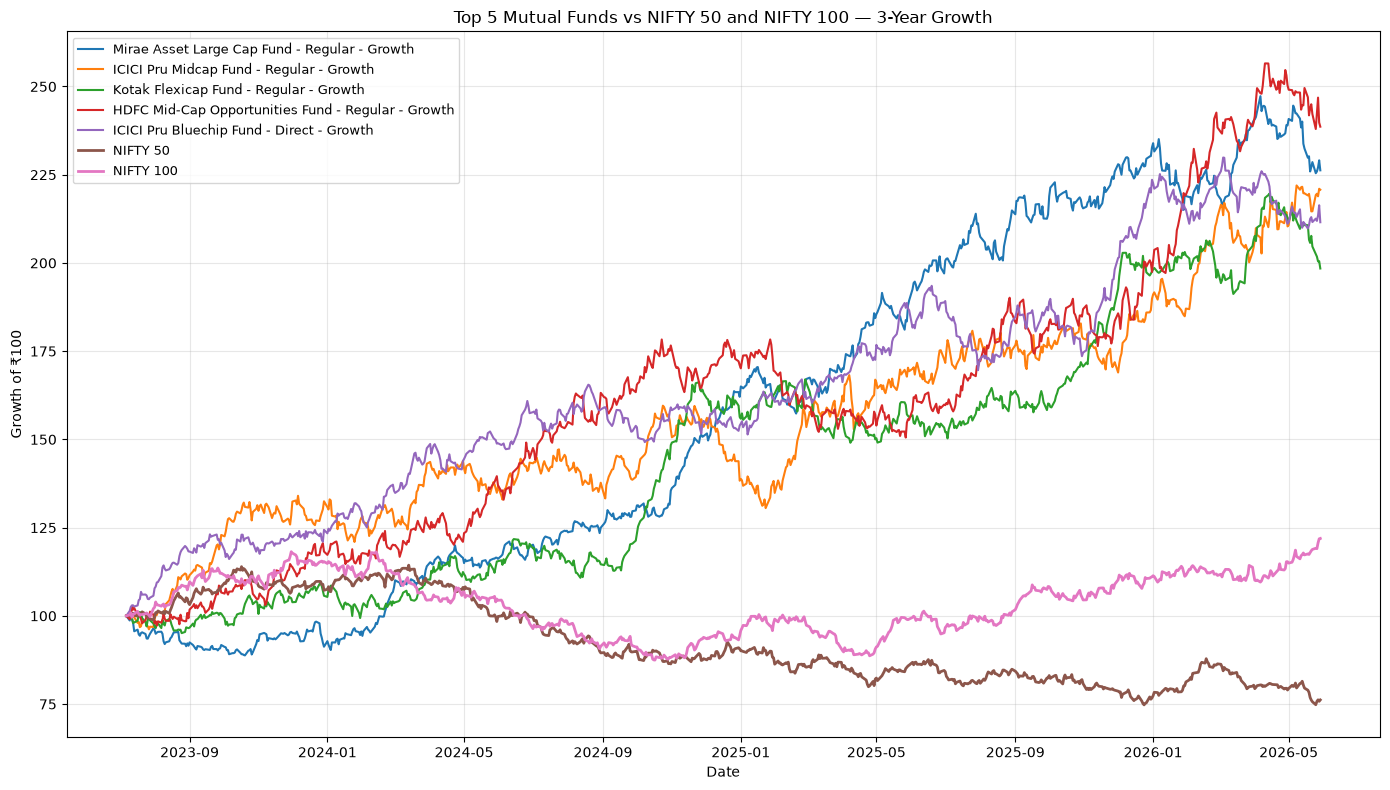

Chart saved successfully:
C:\Users\Harishankar\project\data\processed\benchmark_chart.png


In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for amfi_code in top_5_codes:

    fund_data = comparison_data[
        comparison_data["amfi_code"] == amfi_code
    ].sort_values("date")

    scheme_name = scorecard[
        scorecard["amfi_code"] == amfi_code
    ]["scheme_name"].iloc[0]

    plt.plot(
        fund_data["date"],
        fund_data["fund_growth"],
        label=scheme_name
    )


# Plot NIFTY 50
plt.plot(
    benchmark_growth["date"],
    benchmark_growth["nifty50_growth"],
    label="NIFTY 50",
    linewidth=2
)


# Plot NIFTY 100
plt.plot(
    benchmark_growth["date"],
    benchmark_growth["nifty100_growth"],
    label="NIFTY 100",
    linewidth=2
)


plt.title(
    "Top 5 Mutual Funds vs NIFTY 50 and NIFTY 100 — 3-Year Growth"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.legend(
    loc="best",
    fontsize=9
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

chart_path = os.path.join(
    processed_path,
    "benchmark_chart.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully:")
print(chart_path)